# Stage 03: Python Fundamentals

This notebook practices NumPy vectorization, pandas inspection and groupby analysis using an illustrative market-stress dataset for the S&P 500 volatility project.

In [1]:
from pathlib import Path
import sys
import timeit

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

REPO_ROOT = next(
    parent for parent in [Path.cwd(), *Path.cwd().parents]
    if (parent / 'homework' / 'homework03').exists()
)
HOMEWORK_DIR = REPO_ROOT / 'homework' / 'homework03'
RAW_DATA_PATH = HOMEWORK_DIR / 'data' / 'raw' / 'starter_data.csv'
PROCESSED_DIR = HOMEWORK_DIR / 'data' / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(HOMEWORK_DIR / 'src'))
from utils import get_summary_stats

/Users/yifang/.matplotlib is not a writable directory


Matplotlib created a temporary cache directory at /var/folders/s5/8svqh9px7c37nc9bv7gsq6gh0000gn/T/matplotlib-8dy3dhnm because there was an issue with the default path (/Users/yifang/.matplotlib); it is highly recommended to set the MPLCONFIGDIR environment variable to a writable directory, in particular to speed up the import of Matplotlib and to better support multiprocessing.


Matplotlib is building the font cache; this may take a moment.


## 1. NumPy Operations
Create an array from the VIX values and use vectorized operations to calculate changes and identify elevated readings.

In [2]:
raw_data = pd.read_csv(RAW_DATA_PATH)
vix_values = raw_data['vix'].to_numpy()

vix_changes = np.diff(vix_values)
elevated_vix = vix_values[vix_values >= 17]

print(f'Average VIX: {vix_values.mean():.2f}')
print(f'Maximum VIX: {vix_values.max():.2f}')
print(f'Observations with VIX >= 17: {elevated_vix.size}')
vix_changes

Average VIX: 16.63
Maximum VIX: 18.60
Observations with VIX >= 17: 5


array([ 0.8, -1.4, -0.8,  1.7, -2.1, -0.6,  1.6, -0.7, -1.4,  1.9, -1.7])

## 2. Compare Loop vs. Vectorization
Both functions calculate daily percent changes. The vectorized NumPy version should be faster because it avoids a Python-level loop.

In [3]:
prices = np.tile(raw_data['sp500_close'].to_numpy(), 1_000)

def returns_with_loop(values):
    return np.array([
        (values[index] - values[index - 1]) / values[index - 1]
        for index in range(1, len(values))
    ])

def returns_vectorized(values):
    return np.diff(values) / values[:-1]

loop_seconds = timeit.timeit(lambda: returns_with_loop(prices), number=100)
vectorized_seconds = timeit.timeit(lambda: returns_vectorized(prices), number=100)

speed_comparison = pd.DataFrame({
    'method': ['Python loop', 'NumPy vectorization'],
    'seconds_for_100_runs': [loop_seconds, vectorized_seconds],
})
speed_comparison['speedup_vs_loop'] = loop_seconds / speed_comparison['seconds_for_100_runs']
speed_comparison

,method,seconds_for_100_runs,speedup_vs_loop
0,Python loop,0.196812,1.00000
1,NumPy vectorization,0.002740,71.82061


## 3. Load and Inspect Dataset
Load the CSV with pandas, inspect its structure, and review descriptive statistics for numeric columns.

In [4]:
market_data = pd.read_csv(RAW_DATA_PATH, parse_dates=['date'])
market_data.info()
market_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12 entries, 0 to 11
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   date           12 non-null     datetime64[ns]
 1   sp500_close    12 non-null     int64         
 2   vix            12 non-null     float64       
 3   treasury_10y   12 non-null     float64       
 4   market_regime  12 non-null     object        
dtypes: datetime64[ns](1), float64(2), int64(1), object(1)
memory usage: 608.0+ bytes


,date,sp500_close,vix,treasury_10y,market_regime
0,2026-01-02,5968,17.8,4.22,Elevated
1,2026-01-05,5942,18.6,4.24,Elevated
2,2026-01-06,6001,17.2,4.20,Normal
3,2026-01-07,6028,16.4,4.18,Normal
4,2026-01-08,5989,18.1,4.21,Elevated


In [5]:
numeric_summary = market_data.select_dtypes(include='number').describe().T
numeric_summary.to_csv(PROCESSED_DIR / 'numeric_summary.csv')
numeric_summary

,count,mean,std,min,25%,50%,75%,max
sp500_close,12.0,6036.416667,53.467846,5942.0,5998.0000,6041.000,6073.5000,6115.00
vix,12.0,16.633333,1.179625,14.9,15.8500,16.600,17.3500,18.60
treasury_10y,12.0,4.173333,0.041633,4.1,4.1475,4.175,4.2025,4.24


## 4. Summary Statistics and Groupby
Use the reusable function in `src/utils.py` to summarize each market regime, then save the required output.

In [6]:
regime_summary = get_summary_stats(market_data, 'market_regime')
regime_summary.to_csv(PROCESSED_DIR / 'summary.csv', index=False)
regime_summary

,market_regime,sp500_close_mean,sp500_close_median,sp500_close_min,sp500_close_max,vix_mean,vix_median,vix_min,vix_max,treasury_10y_mean,treasury_10y_median,treasury_10y_min,treasury_10y_max
0,Elevated,6002.800000,5989.0,5942,6078,17.66,17.8,16.8,18.6,4.200000,4.21,4.14,4.24
1,Normal,6060.428571,6058.0,6001,6115,15.90,16.0,14.9,17.2,4.154286,4.16,4.10,4.20


## 5. Bonus: Basic Plot
The chart is saved to `data/processed/vix_by_date.png` for later reporting.

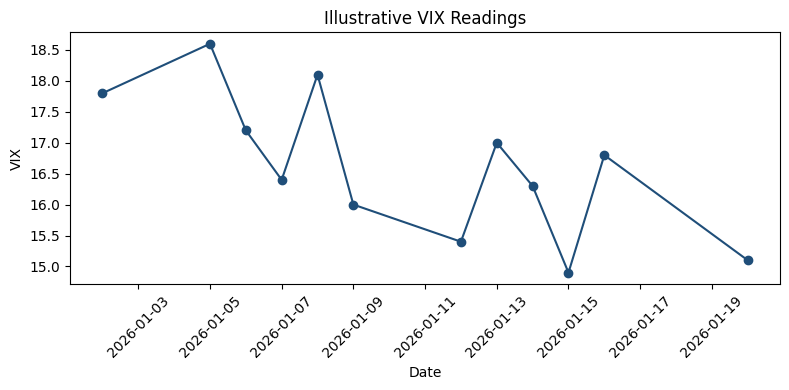

In [7]:
plt.figure(figsize=(8, 4))
plt.plot(market_data['date'], market_data['vix'], marker='o', color='#1f4e79')
plt.title('Illustrative VIX Readings')
plt.xlabel('Date')
plt.ylabel('VIX')
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig(PROCESSED_DIR / 'vix_by_date.png', dpi=150)
plt.show()

## Conclusion
This homework demonstrates vectorized numerical work, CSV loading and inspection, descriptive statistics, grouped summaries, saved outputs, and a reusable utility function.